# Exemplo de Redução de Dimensionalidade

Primeiro, vamos inserir as bibliotecas do Python que serão usadas.

In [8]:
%matplotlib inline

import os

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from keras.preprocessing import image

Vamos então baixar a nossa imagem de exemplo.

In [7]:
!wget https://raw.githubusercontent.com/mohammadimtiazz/standard-test-images-for-Image-Processing/refs/heads/master/standard_test_images/tulips.png

--2025-04-30 02:19:58--  https://raw.githubusercontent.com/mohammadimtiazz/standard-test-images-for-Image-Processing/refs/heads/master/standard_test_images/tulips.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 679233 (663K) [image/png]
Saving to: ‘tulips.png’

tulips.png          100%[===================>] 663.31K  --.-KB/s    in 0.02s   

2025-04-30 02:19:58 (32.3 MB/s) - ‘tulips.png’ saved [679233/679233]



Vamos então exibir em tela.

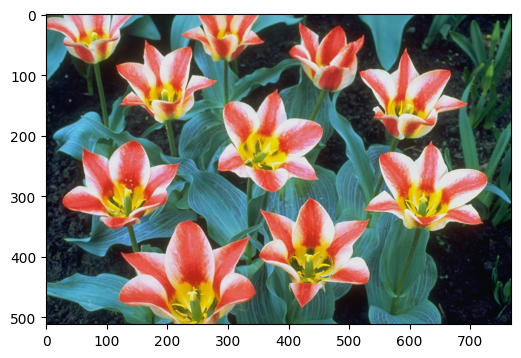

In [12]:
img = image.load_img('tulips.png')
plt.figure(figsize=(6,6))
plt.imshow(img)

Agora vamos analizar, pixel a pixel, qual a média dos valores R, G e B. Com isso, formaremos a nossa imagem em tons de cinza.

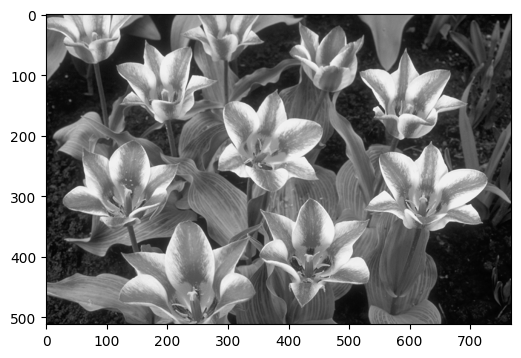

In [23]:
img_array = image.img_to_array(img)
width = len(img_array[0])
height = len(img_array)
for x in range(width):
  for y in range(height):
    avg = int(np.average(img_array[y][x]))
    img_array[y][x] = [avg, avg, avg]
gray_img = image.array_to_img(img_array)
plt.figure(figsize=(6,6))
plt.imshow(gray_img)

Tendo feito isso, vamos usar esta imagem como base para a nossa imagem em preto e branco. Basicamente, para cada pixel, vamos analizar se o pixel tem valor maior (branco) ou menor (preto) do que 127.

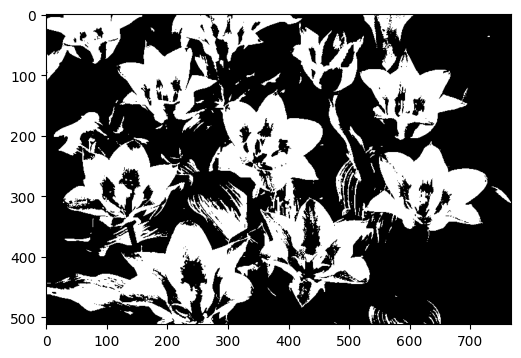

In [25]:
gray_img_array = image.img_to_array(gray_img)
for x in range(width):
  for y in range(height):
    avg = 1 if gray_img_array[y][x][0] > 127 else 0
    gray_img_array[y][x] = [avg, avg, avg]
bw_img = image.array_to_img(gray_img_array)
plt.figure(figsize=(6,6))
plt.imshow(bw_img)

Por fim, vejamos o resultado lado a lado.

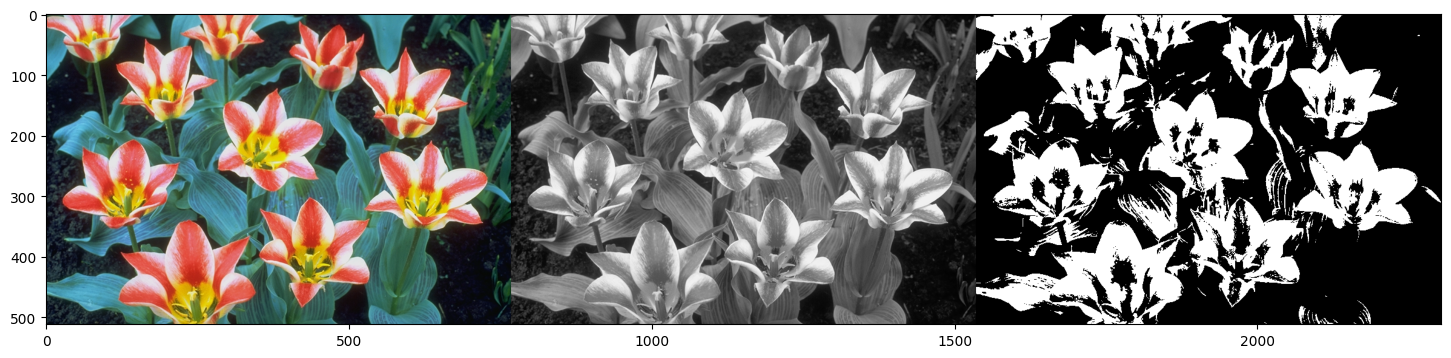

In [27]:
concat_image = np.concatenate([img, gray_img, bw_img], axis=1)
plt.figure(figsize=(18, 6))
plt.imshow(concat_image)